# Data Description

This notebook performs EDA on the KKBox churn dataset to understand feature distributions, class imbalance, and relationships before model training.

Source: (https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge/data)

## train_v2.csv
the train set, containing the user ids and whether they have churned.

**msno**: user id

**is_churn**: This is the target variable. Churn is defined as whether the user did not continue the subscription within 30 days of expiration. is_churn = 1 means churn, is_churn = 0 means renewal.

## transactions_v2.csv

**msno**: user id

**payment_method_id**: payment method

**payment_plan_days**: length of membership plan in days

**plan_list_price**: in New Taiwan Dollar (NTD)

**actual_amount_paid**: in New Taiwan Dollar (NTD)

**is_auto_renew**: whether the subscription auto-renews

**transaction_date**: format %Y%m%d

**membership_expire_date**: format %Y%m%d

**is_cancel**: whether or not the user canceled the membership in this transaction.

## user_logs_v2.csv

**msno**: user id

**date**: format %Y%m%d

**num_25**: # of songs played less than 25% of the song length

**num_50**: # of songs played between 25% to 50% of the song length

**num_75**: # of songs played between 50% to 75% of the song length

**num_985**: # of songs played between 75% to 98.5% of the song length

**num_100**: # of songs played over 98.5% of the song length

**num_unq**: # of unique songs played

**total_secs**: total seconds played

## members_v3.csv

**msno**: user id

**city**

**bd**: age. Note: this column has outlier values ranging from -7000 to 2015, please use your judgement.

**gender**

**registered_via**: registration method

**registration_init_time**: format %Y%m%d

**expiration_date**: format %Y%m%d, taken as a snapshot at which the member.csv is extracted. Not representing the actual churn behavior.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, xticks
import os

DATA_DIR = os.path.join(os.path.dirname(__file__), '..', '..', 'data', 'raw') if '__file__' in dir() else '../../data/raw'

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_v2.csv'))
df_member = pd.read_csv(os.path.join(DATA_DIR, 'members_v3.csv'))
df_transaction = pd.read_csv(os.path.join(DATA_DIR, 'transactions_v2.csv'))
df_log = pd.read_csv(os.path.join(DATA_DIR, 'user_logs_v2.csv'))

df_train.head()

,msno,is_churn
0,jPnRUrxEFZ71o38gwQSgkyja56Mz8NUK+Q3d6yBQNYg=,0
1,O35R1RlzfsyTF7wW6FqNfHOUiKmOfq0p4LtPLuwH+y4=,0
2,T2kAaQkKHy1k08W1ExIi47cUy4Q7eX00Vk5S6e46rj0=,0
3,iGpjQPGF+N55O6WJTrEe3G8lru7L0kP2L+RaKDkj9cQ=,0
4,60jtevvlQVTsNnVHqaw/UTwQ/gh1Az6LnCLSdDeNEPQ=,0


In [2]:
df_member.head()


,msno,city,bd,gender,registered_via,registration_init_time
0,Xu8NWVApL13fqXD8N1vGafCLxVSw/FSOgUaJo5EdehM=,13,0,NaN,7,20111008
1,lYrf6Y/NjJ8yDGp51Nb537ZZ3bjy2ZmvjCE6Qgj53NM=,1,0,NaN,7,20111015
2,m0h0+lJIok7k6BzAoOnq+x+mB1tbi9shGF/egYLbed4=,4,22,female,7,20141020
3,7oCpSPj4+SdVJLfDRc+tN5HLp2R1DRozaWsTpbLTz5g=,15,21,female,3,20141020
4,eIOUZ5I+NV/3EDfn/U/tMepn4FJt2SdzOrWGH1tNlYI=,5,24,male,3,20141025


In [3]:
df_transaction.head()


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,+3Z/2l0S7ui1s9FlZgsPYPUm3VOBhZGgW5toALP8VOg=,41,30,149,149,1,20150731,20171202,0
1,+80beh2T6i0UctXvcbhoGWaxqAWE0KMnACtHDItZvpU=,41,30,99,99,1,20170327,20170427,0
2,+C42tIh4KdXUBTAje2rhUSvVtw7NPBkWqzfwajppZoQ=,41,30,99,99,1,20170326,20170426,0
3,+KK1bGUQv8VsWuplM0oMy2++HX2nC06otNzG/f7xrsU=,41,30,99,99,1,20170314,20170414,0
4,+L/XrtIg0DD9ku+ik959EtrnRQfLyf/P6GD1Z8HbkP4=,33,30,149,149,1,20170331,20170430,0


In [4]:
df_log.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
1,zv12NEuyP2XxcgTDu89mGnPLdnfq8xhBY4jQl8JYLxk=,20170325,5,3,2,1,34,43,9060.814
2,J0BhO71yiNuIbyK+QkzR2Ih1PXarheWYO3EcZIQk5NQ=,20170316,0,0,0,0,3,3,697.004
3,c8bRbZBn+OLkpwumBFhqHAxPe1Luzbwd6gcyHvyl9K0=,20170311,6,1,1,0,10,15,3529.431
4,5q47XHnBIXfWVTk00FFP19zhu5KG2fB7E2u5L+hBZR4=,20170310,13,0,2,4,140,78,33449.000


## 1. Data Cleaning

### Null Handling Strategy per Column

All cleansing rules are also documented in `config/cleansing_rules.yaml`.

| Table | Column | Nulls Found | Strategy |
|---|---|---|---|
| **train** | `msno` | 0 | Drop row if null (primary key) |
| | `is_churn` | 0 | Drop row if null (target) |
| **members** | `msno` | 0 | Drop row if null (primary key) |
| | `city` | 0 | Keep as-is |
| | `bd` | Implicitly many (outliers set to NaN) | Replace values < 18 or > 90 with NaN, then impute with **median** |
| | `gender` | 94 517 (>50 %) | **Drop column** — too many missing values to impute reliably |
| | `registered_via` | 0 | Keep as-is |
| | `registration_init_time` | 0 | Keep as-is |
| **transactions** | `msno` | 0 | Keep as-is |
| | `payment_method_id` | 0 | Keep as-is |
| | `payment_plan_days` | 0 | Keep as-is |
| | `plan_list_price` | 0 | Keep as-is |
| | `actual_amount_paid` | 0 | Keep as-is |
| | `is_auto_renew` | 0 | Keep as-is |
| | `transaction_date` | 0 | Keep as-is |
| | `membership_expire_date` | 0 | Keep as-is |
| | `is_cancel` | 0 | Keep as-is |
| **user_logs** | All columns | 0 | Keep as-is — user_logs contains ~2.55 M rows with heavy `msno` duplication (daily listening records per user) and requires separate aggregation before it can be joined. This EDA focuses on member demographics and transaction-derived features, so user_logs is not merged into the final dataset here. |

In [5]:
print(f"df_train has duplicates: {df_train.msno.duplicated().any()}")
print(f"df_member has duplicates: {df_member.msno.duplicated().any()}")
print(f"df_transaction has duplicates: {df_transaction.msno.duplicated().any()}")
print(f"df_log has duplicates: {df_log.msno.duplicated().any()}")

print(f"\n--- Duplicate counts ---")
print(f"train:        {df_train.msno.duplicated().sum()} duplicate rows")
print(f"members:      {df_member.msno.duplicated().sum()} duplicate rows")
print(f"transactions: {df_transaction.msno.duplicated().sum()} duplicate rows (to be aggregated per msno)")
print(f"user_logs:    {df_log.msno.duplicated().sum()} duplicate rows")

df_train has duplicates: False
df_member has duplicates: False
df_transaction has duplicates: True
df_log has duplicates: True

--- Duplicate counts ---
train:        0 duplicate rows
members:      0 duplicate rows
transactions: 39430 duplicate rows (to be aggregated per msno)
user_logs:    2554289 duplicate rows


### Transaction Table — Null check, type casting & duplicate aggregation

In [6]:
df_transaction.isnull().sum()

msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32],
 [Text(0, 0, '3'),
  Text(1, 0, '6'),
  Text(2, 0, '8'),
  Text(3, 0, '10'),
  Text(4, 0, '11'),
  Text(5, 0, '12'),
  Text(6, 0, '13'),
  Text(7, 0, '14'),
  Text(8, 0, '15'),
  Text(9, 0, '16'),
  Text(10, 0, '17'),
  Text(11, 0, '18'),
  Text(12, 0, '19'),
  Text(13, 0, '20'),
  Text(14, 0, '21'),
  Text(15, 0, '22'),
  Text(16, 0, '23'),
  Text(17, 0, '26'),
  Text(18, 0, '27'),
  Text(19, 0, '28'),
  Text(20, 0, '29'),
  Text(21, 0, '30'),
  Text(22, 0, '31'),
  Text(23, 0, '32'),
  Text(24, 0, '33'),
  Text(25, 0, '34'),
  Text(26, 0, '35'),
  Text(27, 0, '36'),
  Text(28, 0, '37'),
  Text(29, 0, '38'),
  Text(30, 0, '39'),
  Text(31, 0, '40'),
  Text(32, 0, '41')])

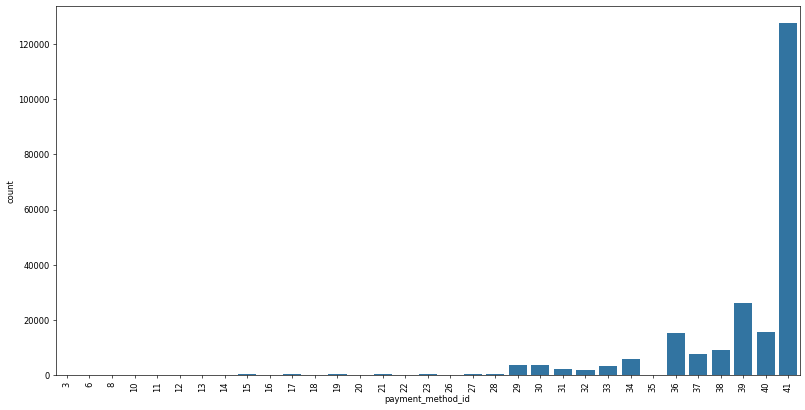

In [7]:
figure(num=None, figsize=(16,8), dpi=60)
sns.countplot(x='payment_method_id', data = df_transaction)
xticks(rotation = 90)


In [8]:
print("--- Data types BEFORE casting ---")
print(f"payment_method_id: {df_transaction.payment_method_id.dtype}")
print(f"transaction_date:  {df_transaction.transaction_date.dtype}")
print(f"membership_expire_date: {df_transaction.membership_expire_date.dtype}")
print(f"registration_init_time (members): {df_member.registration_init_time.dtype}")
print(f"bd (members): {df_member.bd.dtype}")

--- Data types BEFORE casting ---
payment_method_id: int64
transaction_date:  int64
membership_expire_date: int64
registration_init_time (members): int64
bd (members): int64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, '1'),
  Text(1, 0, '15'),
  Text(2, 0, '17'),
  Text(3, 0, '19'),
  Text(4, 0, '21'),
  Text(5, 0, '23'),
  Text(6, 0, '27'),
  Text(7, 0, '28'),
  Text(8, 0, '29'),
  Text(9, 0, '30'),
  Text(10, 0, '31'),
  Text(11, 0, '32'),
  Text(12, 0, '33'),
  Text(13, 0, '34'),
  Text(14, 0, '35'),
  Text(15, 0, '36'),
  Text(16, 0, '37'),
  Text(17, 0, '38'),
  Text(18, 0, '39'),
  Text(19, 0, '40'),
  Text(20, 0, '41')])

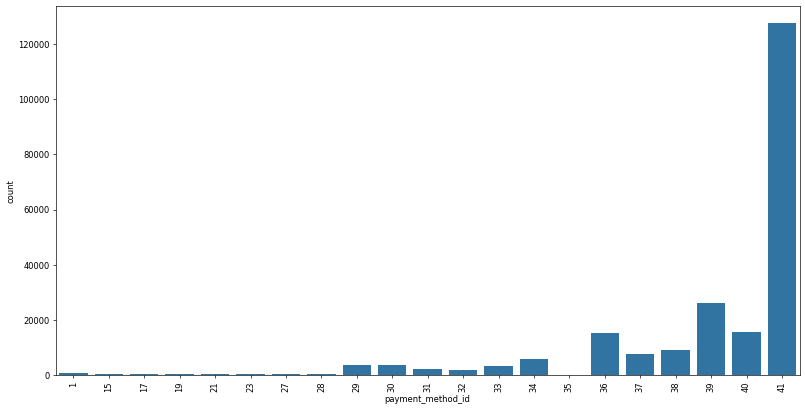

In [9]:
from pandas.core.indexes import category
# Replacing low frequencies to a new collective category
df_transaction.payment_method_id = df_transaction.payment_method_id.replace(
    [3, 6, 8, 10, 11, 12, 13, 14, 16, 18, 20, 22, 26], 1
)
df_transaction.payment_method_id = df_transaction.payment_method_id.astype('category')
figure(num=None, figsize=(16,8), dpi=60)
sns.countplot(x='payment_method_id', data = df_transaction)
xticks(rotation = 90)

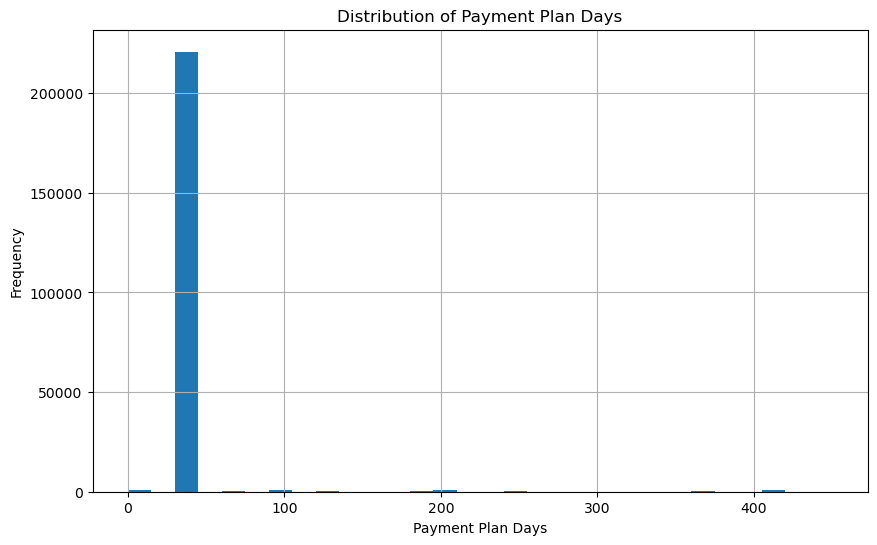

In [10]:
plt.figure(figsize=(10, 6))
df_transaction['payment_plan_days'].hist(bins=30)
plt.title('Distribution of Payment Plan Days')
plt.xlabel('Payment Plan Days')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<Axes: xlabel='plan_list_price'>

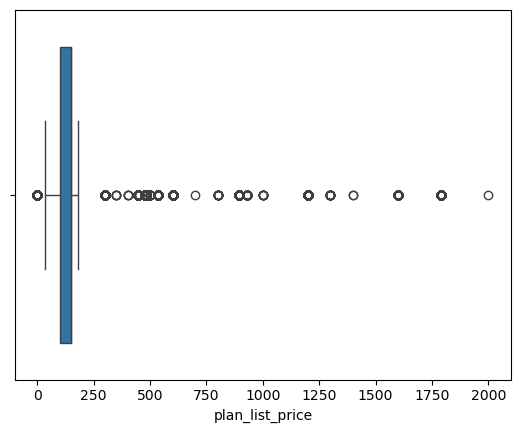

In [11]:
sns.boxplot(x='plan_list_price', data = df_transaction)

<Axes: xlabel='is_auto_renew', ylabel='count'>

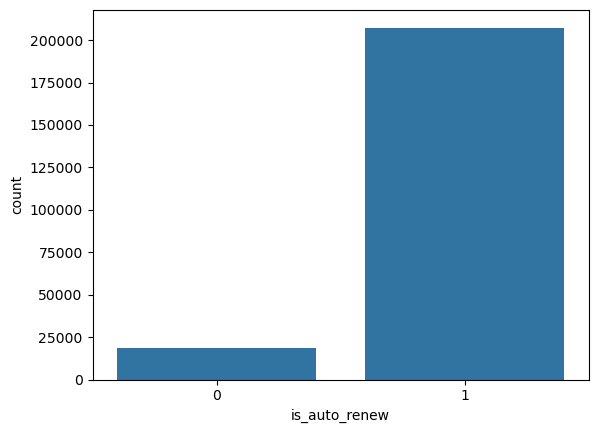

In [12]:
sns.countplot(x='is_auto_renew', data = df_transaction)

In [13]:
# Process duplicates in transactions table
df_duplicate_msno = df_transaction[df_transaction.duplicated(subset=['msno'])]
duplicated_msno = df_duplicate_msno.msno.unique()
transaction_group = df_transaction.groupby('msno')
df_transaction_uniq = pd.DataFrame(data = None, columns=[
    'msno','payment_method_id','total_payment_plan_days','total_plan_list_price',
    'total_actual_amount_paid', 'last_plan_days', 'last_plan_price', 'is_auto_renewal', 'first_transaction_date', 'last_transaction_date',
    'membership_expire_date', 'is_cancel', 'no_of_transactions'
])

for msno in duplicated_msno:
    msno_group = transaction_group.get_group(msno)
    payment_method_id = msno_group.payment_method_id.iloc[0]
    total_payment_plan_days = msno_group.payment_plan_days.sum()
    total_plan_list_price = msno_group.plan_list_price.sum()
    total_actual_amount_paid = msno_group.actual_amount_paid.sum()
    is_auto_renewal = msno_group.is_auto_renew.iloc[0]
    first_transaction_date = msno_group.transaction_date.min()
    last_transaction_date = msno_group.transaction_date.max()
    membership_expire_date = msno_group.membership_expire_date.max()
    last_date = msno_group[msno_group.transaction_date==last_transaction_date]
    last_plan_days = 0
    last_plan_price = 0
    if len(last_date)>0:
        last_plan_days = last_date['payment_plan_days'].values.max()
        last_plan_price = last_date['plan_list_price'].values.max()
    canceled = msno_group.is_cancel.values
    is_cancel = 0 if 1 in canceled else 1
    no_of_transactions = len(msno_group)
    pointer = len(df_transaction_uniq)
    df_transaction_uniq.loc[pointer] = [
        msno, payment_method_id, total_payment_plan_days, total_plan_list_price,
        total_actual_amount_paid, last_plan_days, last_plan_price, is_auto_renewal, first_transaction_date, last_transaction_date,
        membership_expire_date, is_cancel, no_of_transactions
    ]
df_transaction_uniq.head()

,msno,payment_method_id,total_payment_plan_days,total_plan_list_price,total_actual_amount_paid,last_plan_days,last_plan_price,is_auto_renewal,first_transaction_date,last_transaction_date,membership_expire_date,is_cancel,no_of_transactions
0,/BndJt9YSOh1kzEykXyHrQZKl943rqFrzR9efW2b7wE=,39,60,298,298,30,149,1,20170228,20170331,20170524,1,2
1,Du6MaYC9gJo8KEu2QVKWpzl448tbmM2iTImTAHAg8EY=,41,1050,5195,5344,30,129,1,20150115,20170312,20200516,1,36
2,EHm4AZVfQdBoG27szXUO8Di8j43e3vjBC8Bb5W3BWpM=,41,630,3129,3129,30,149,1,20150314,20170314,20181115,1,21
3,EUeMl8RuZ6UZncTAHta9Go5jATXPtAm4k1Fu6EIIGZ8=,41,750,3725,3813,30,149,1,20150321,20151221,20190522,0,27
4,O31M5U9pLN3rTC/LgL5luolj7GrCanKRQSa3o+xR/iA=,39,60,298,298,30,149,1,20170228,20170331,20170529,1,2


In [14]:
# Add back single-transaction users
single_msno = df_transaction[
    ~df_transaction.duplicated(subset=['msno'], keep=False)]
single_msno.duplicated(subset="msno").sum()

np.int64(0)

In [15]:
len(single_msno)

163726

In [16]:
single_msno_processed = pd.DataFrame({
    "msno": single_msno["msno"],
    "payment_method_id": single_msno["payment_method_id"],
    "total_payment_plan_days": single_msno["payment_plan_days"],
    "total_plan_list_price": single_msno["plan_list_price"],
    "total_actual_amount_paid": single_msno["actual_amount_paid"],
    "last_plan_days": single_msno["payment_plan_days"],
    "last_plan_price": single_msno["plan_list_price"],
    "is_auto_renewal": single_msno["is_auto_renew"],
    "first_transaction_date": single_msno["transaction_date"],
    "last_transaction_date": single_msno["transaction_date"],
    "membership_expire_date": single_msno["membership_expire_date"],
    "is_cancel": single_msno["is_cancel"],
    "no_of_transactions": 1
})

In [17]:
df_transaction_final = pd.concat(
    [df_transaction_uniq, single_msno_processed],
    ignore_index=True
)
len(df_transaction_final)

186713

In [18]:
df_transaction_final.isna().sum()

msno                        0
payment_method_id           0
total_payment_plan_days     0
total_plan_list_price       0
total_actual_amount_paid    0
last_plan_days              0
last_plan_price             0
is_auto_renewal             0
first_transaction_date      0
last_transaction_date       0
membership_expire_date      0
is_cancel                   0
no_of_transactions          0
dtype: int64

In [19]:
del df_transaction
del df_transaction_uniq
del single_msno
del single_msno_processed

### Member Table — Null check, outlier treatment & type casting

In [20]:
df_member.isnull().sum()

msno                          0
city                          0
bd                            0
gender                    94517
registered_via                0
registration_init_time        0
dtype: int64

<Axes: xlabel='city', ylabel='count'>

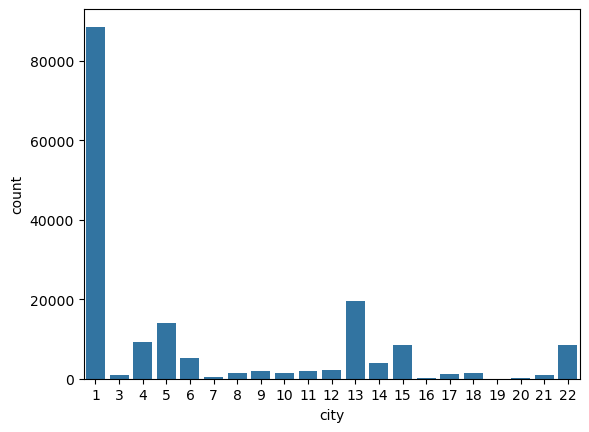

In [21]:
sns.countplot(x='city', data = df_member)

<Axes: xlabel='gender', ylabel='count'>

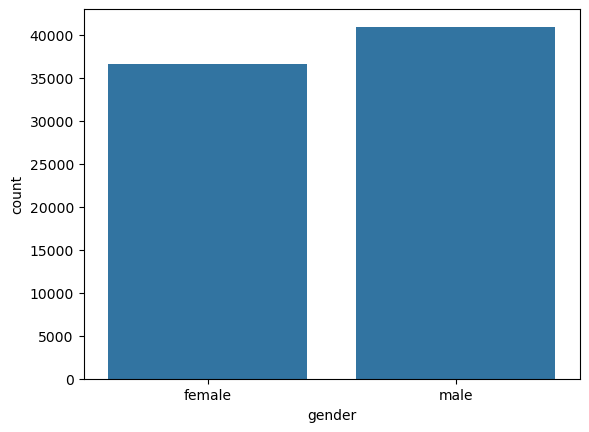

In [22]:
sns.countplot(x='gender', data = df_member)

#### Gender Column — Decision to Drop

There are 94,517 missing entries in `gender` (>50% of rows). Since imputing a categorical variable with this level of missingness would be unreliable, the column is dropped.

<Axes: xlabel='bd'>

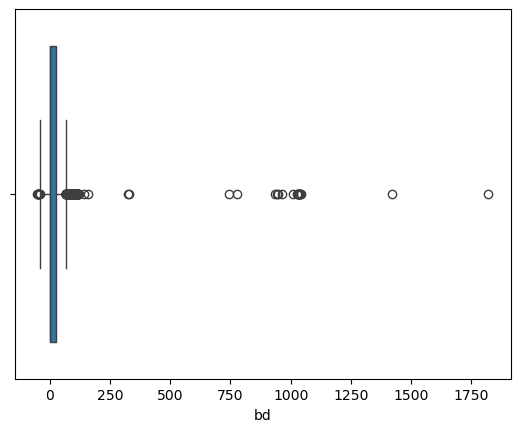

In [23]:
# Addressing abnormal values of bd: age
sns.boxplot(x='bd', data = df_member)

In [24]:
df_member['bd'].median()

0.0

/var/folders/h1/0lk6w58x29g1pn67zqzwqt9c0000gn/T/ipykernel_11346/139180847.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_member['bd'].fillna(df_member['bd'].median(), inplace=True)


<Axes: xlabel='bd'>

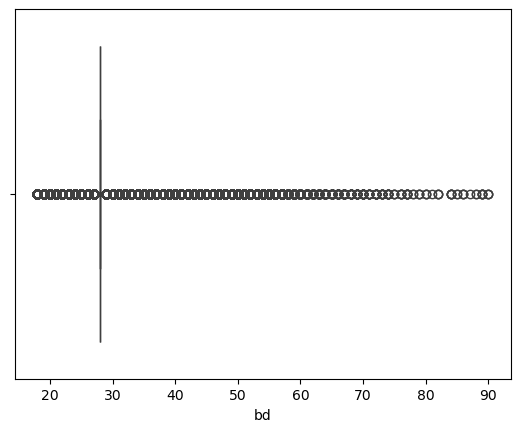

In [25]:
# Replace Abnormal values as missing
df_member.loc[df_member.bd < 18, 'bd'] = np.nan
df_member.loc[df_member.bd > 90, 'bd'] = np.nan
#Replacing with Median because the variable is severely skewed
df_member['bd'].fillna(df_member['bd'].median(), inplace=True)
sns.boxplot(x='bd', data = df_member)

In [26]:
df_member.bd.describe()

count    172033.000000
mean         28.977243
std           5.858089
min          18.000000
25%          28.000000
50%          28.000000
75%          28.000000
max          90.000000
Name: bd, dtype: float64

<Axes: xlabel='registered_via', ylabel='count'>

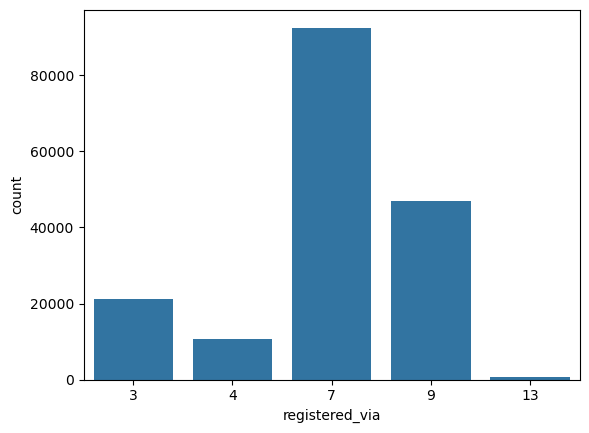

In [27]:
sns.countplot(x='registered_via', data = df_member)


In [28]:
# Merge transaction data with member profiles
df_member_transaction = pd.merge(
    df_member, df_transaction_final, how='inner', on='msno')
len(df_member_transaction)

164911

In [29]:
df_member_transaction.head()

,msno,city,bd,gender,registered_via,registration_init_time,payment_method_id,total_payment_plan_days,total_plan_list_price,total_actual_amount_paid,last_plan_days,last_plan_price,is_auto_renewal,first_transaction_date,last_transaction_date,membership_expire_date,is_cancel,no_of_transactions
0,Xu8NWVApL13fqXD8N1vGafCLxVSw/FSOgUaJo5EdehM=,13,28.0,NaN,7,20111008,37,30,149,149,30,149,1,20170301,20170301,20170414,0,1
1,lYrf6Y/NjJ8yDGp51Nb537ZZ3bjy2ZmvjCE6Qgj53NM=,1,28.0,NaN,7,20111015,41,30,149,149,30,149,1,20170314,20170314,20170415,0,1
2,m0h0+lJIok7k6BzAoOnq+x+mB1tbi9shGF/egYLbed4=,4,22.0,female,7,20141020,36,30,180,180,30,180,1,20170316,20170316,20170415,0,1
3,7oCpSPj4+SdVJLfDRc+tN5HLp2R1DRozaWsTpbLTz5g=,15,21.0,female,3,20141020,40,60,298,298,30,149,1,20170224,20170324,20170527,1,2
4,eIOUZ5I+NV/3EDfn/U/tMepn4FJt2SdzOrWGH1tNlYI=,5,24.0,male,3,20141025,36,30,180,180,30,180,1,20170312,20170312,20170411,0,1


In [30]:
df_member_transaction['registration_init_time'] = pd.to_datetime(df_member_transaction['registration_init_time'], format='%Y%m%d')
df_member_transaction['first_transaction_date'] = pd.to_datetime(df_member_transaction['first_transaction_date'], format='%Y%m%d')
df_member_transaction['last_transaction_date'] = pd.to_datetime(df_member_transaction['last_transaction_date'], format='%Y%m%d')
df_member_transaction['membership_expire_date'] = pd.to_datetime(df_member_transaction['membership_expire_date'], format='%Y%m%d')

In [31]:
print("--- Data types AFTER casting ---")
print(f"payment_method_id: {df_member_transaction.payment_method_id.dtype}")
print(f"registration_init_time: {df_member_transaction.registration_init_time.dtype}")
print(f"first_transaction_date: {df_member_transaction.first_transaction_date.dtype}")
print(f"last_transaction_date: {df_member_transaction.last_transaction_date.dtype}")
print(f"membership_expire_date: {df_member_transaction.membership_expire_date.dtype}")
print(f"bd: {df_member_transaction.bd.dtype}")

--- Data types AFTER casting ---
payment_method_id: int64
registration_init_time: datetime64[ns]
first_transaction_date: datetime64[ns]
last_transaction_date: datetime64[ns]
membership_expire_date: datetime64[ns]
bd: float64


In [32]:
df_member_transaction = df_member_transaction.drop(columns=['gender'])

In [33]:
print(f"df_train has duplicates in 'msno': {df_train.msno.duplicated().any()}")

df_train has duplicates in 'msno': False


In [34]:
# Merge churn labels with member/transaction profiles
df_train_final = pd.merge(
    df_train, df_member_transaction, how='inner', on='msno')
len(df_train_final)

164911

In [35]:
date_columns = ['registration_init_time', 'first_transaction_date', 'last_transaction_date', 'membership_expire_date']

for col in date_columns:
    df_train_final[f'{col}_year'] = df_train_final[col].dt.year
    df_train_final[f'{col}_month'] = df_train_final[col].dt.month
    df_train_final[f'{col}_day'] = df_train_final[col].dt.day

df_train_final.head()

,msno,is_churn,city,bd,registered_via,registration_init_time,payment_method_id,total_payment_plan_days,total_plan_list_price,total_actual_amount_paid,...,registration_init_time_day,first_transaction_date_year,first_transaction_date_month,first_transaction_date_day,last_transaction_date_year,last_transaction_date_month,last_transaction_date_day,membership_expire_date_year,membership_expire_date_month,membership_expire_date_day
0,jPnRUrxEFZ71o38gwQSgkyja56Mz8NUK+Q3d6yBQNYg=,0,5,19.0,7,2015-06-19,41,30,99,99,...,19,2017,3,12,2017,3,12,2017,4,12
1,O35R1RlzfsyTF7wW6FqNfHOUiKmOfq0p4LtPLuwH+y4=,0,15,88.0,9,2005-11-02,31,30,149,149,...,2,2017,3,31,2017,3,31,2017,4,30
2,T2kAaQkKHy1k08W1ExIi47cUy4Q7eX00Vk5S6e46rj0=,0,3,21.0,4,2015-11-27,38,30,149,149,...,27,2017,3,24,2017,3,24,2017,4,23
3,iGpjQPGF+N55O6WJTrEe3G8lru7L0kP2L+RaKDkj9cQ=,0,1,28.0,7,2011-10-11,41,30,99,99,...,11,2017,3,14,2017,3,14,2017,4,14
4,60jtevvlQVTsNnVHqaw/UTwQ/gh1Az6LnCLSdDeNEPQ=,0,1,28.0,7,2016-02-05,41,30,99,99,...,5,2017,3,5,2017,3,5,2017,4,5


In [36]:
df_train_final['membership_duration_days'] = (df_train_final['membership_expire_date'] - df_train_final['registration_init_time']).dt.days
df_train_final['transaction_span_days'] = (df_train_final['last_transaction_date'] - df_train_final['first_transaction_date']).dt.days


In [37]:
df_train_final['avg_plan_price'] = df_train_final['total_plan_list_price'] / df_train_final['no_of_transactions']
df_train_final['avg_plan_days'] = df_train_final['total_payment_plan_days'] / df_train_final['no_of_transactions']
df_train_final['amount_due'] = df_train_final['total_plan_list_price']-df_train_final['total_actual_amount_paid']
df_train_final = df_train_final.drop(columns =
                                     [
                                        'total_plan_list_price',
                                        'total_payment_plan_days',
                                        'total_actual_amount_paid',
                                        'first_transaction_date',
                                        'last_transaction_date',
                                        'membership_expire_date',
                                        'registration_init_time'
                                     ])
df_train_final = df_train_final.drop(columns =
                                     [
                                        'registration_init_time_year',
                                        'registration_init_time_month',
                                        'registration_init_time_day',
                                        'first_transaction_date_year',
                                        'first_transaction_date_month',
                                        'first_transaction_date_day',
                                        'last_transaction_date_year',
                                        'last_transaction_date_month',
                                        'last_transaction_date_day',
                                        'membership_expire_date_year',
                                        'membership_expire_date_month',
                                        'membership_expire_date_day'
                                     ])

In [38]:
df_train_final.head()

,msno,is_churn,city,bd,registered_via,payment_method_id,last_plan_days,last_plan_price,is_auto_renewal,is_cancel,no_of_transactions,membership_duration_days,transaction_span_days,avg_plan_price,avg_plan_days,amount_due
0,jPnRUrxEFZ71o38gwQSgkyja56Mz8NUK+Q3d6yBQNYg=,0,5,19.0,7,41,30,99,1,0,1,663,0,99.0,30.0,0
1,O35R1RlzfsyTF7wW6FqNfHOUiKmOfq0p4LtPLuwH+y4=,0,15,88.0,9,31,30,149,1,0,1,4197,0,149.0,30.0,0
2,T2kAaQkKHy1k08W1ExIi47cUy4Q7eX00Vk5S6e46rj0=,0,3,21.0,4,38,30,149,0,0,1,513,0,149.0,30.0,0
3,iGpjQPGF+N55O6WJTrEe3G8lru7L0kP2L+RaKDkj9cQ=,0,1,28.0,7,41,30,99,1,0,1,2012,0,99.0,30.0,0
4,60jtevvlQVTsNnVHqaw/UTwQ/gh1Az6LnCLSdDeNEPQ=,0,1,28.0,7,41,30,99,1,0,1,425,0,99.0,30.0,0


## 2. Exploratory Data Analysis
### 2.1 Churn Rate Analysis

The cells below compute the overall churn rate and break it down by city, payment plan duration, and payment method.

In [39]:
overall_churn_rate = df_train_final['is_churn'].mean()
print(f"Overall Churn Rate: {overall_churn_rate:.4f}")

Overall Churn Rate: 0.0653


In [40]:
churn_rate_by_city = df_train_final.groupby('city')['is_churn'].mean().sort_values(ascending=False)
print("Churn Rate by City:\n", churn_rate_by_city)

Churn Rate by City:
 city
19    0.190476
20    0.105691
8     0.098505
21    0.096842
5     0.095335
15    0.094932
4     0.094451
12    0.091778
22    0.090612
6     0.090033
10    0.089968
14    0.088947
13    0.088267
7     0.082816
3     0.082418
11    0.081159
9     0.078290
18    0.077731
17    0.074357
16    0.048387
1     0.042005
Name: is_churn, dtype: float64


In [41]:
churn_rate_by_payment_plan = df_train_final.groupby('avg_plan_days')['is_churn'].mean().sort_values(ascending=False)
print("Churn Rate by Avg Payment Plan Days:\n", churn_rate_by_payment_plan)

Churn Rate by Avg Payment Plan Days:
 avg_plan_days
0.000000     1.0
82.500000    1.0
61.750000    1.0
63.000000    1.0
63.500000    1.0
            ... 
26.400000    0.0
27.428571    0.0
28.695652    0.0
25.714286    0.0
46.750000    0.0
Name: is_churn, Length: 185, dtype: float64


In [42]:
churn_rate_by_payment_method = df_train_final.groupby('payment_method_id')['is_churn'].mean().sort_values(ascending=False)
print("Churn Rate by Payment Method:\n", churn_rate_by_payment_method)

Churn Rate by Payment Method:
 payment_method_id
32    0.984501
17    0.954545
15    0.934169
35    0.925000
1     0.524467
38    0.219486
28    0.212707
36    0.088583
29    0.080902
30    0.067981
40    0.059038
39    0.047360
33    0.035048
27    0.033994
41    0.031840
23    0.028103
21    0.027174
37    0.026703
19    0.024876
34    0.022953
31    0.018182
Name: is_churn, dtype: float64


#### Key Observations

*   The overall churn rate for the dataset is approximately 0.0653 (6.53%).
*   Churn rates vary significantly by city; for example, City 19 has the highest churn rate at approximately 0.1905 (19.05%), while City 1 has a much lower churn rate of approximately 0.0420 (4.20%).
*   `avg_plan_days` is a derived feature (total plan days / number of transactions) with 185 unique fractional values. Edge-case averages (e.g., 0.0, 61.75, 63.0) show 100% churn rates while others show 0% — these extremes likely reflect very small group sizes (often single users) rather than meaningful patterns. The bulk of users cluster around the standard 30-day plan average.
*   Payment method 32 has an extremely high churn rate of approximately 0.9845 (98.45%). Other methods (17, 15, 35) also show churn rates above 90%, whereas methods like 31, 34, 19, 37, 21, 23, 41, 27, 33, 39, and 40 have much lower churn rates, ranging from 1.8% to 5.9%.

### 2.2 Feature Distributions (Top 10 by Variance)

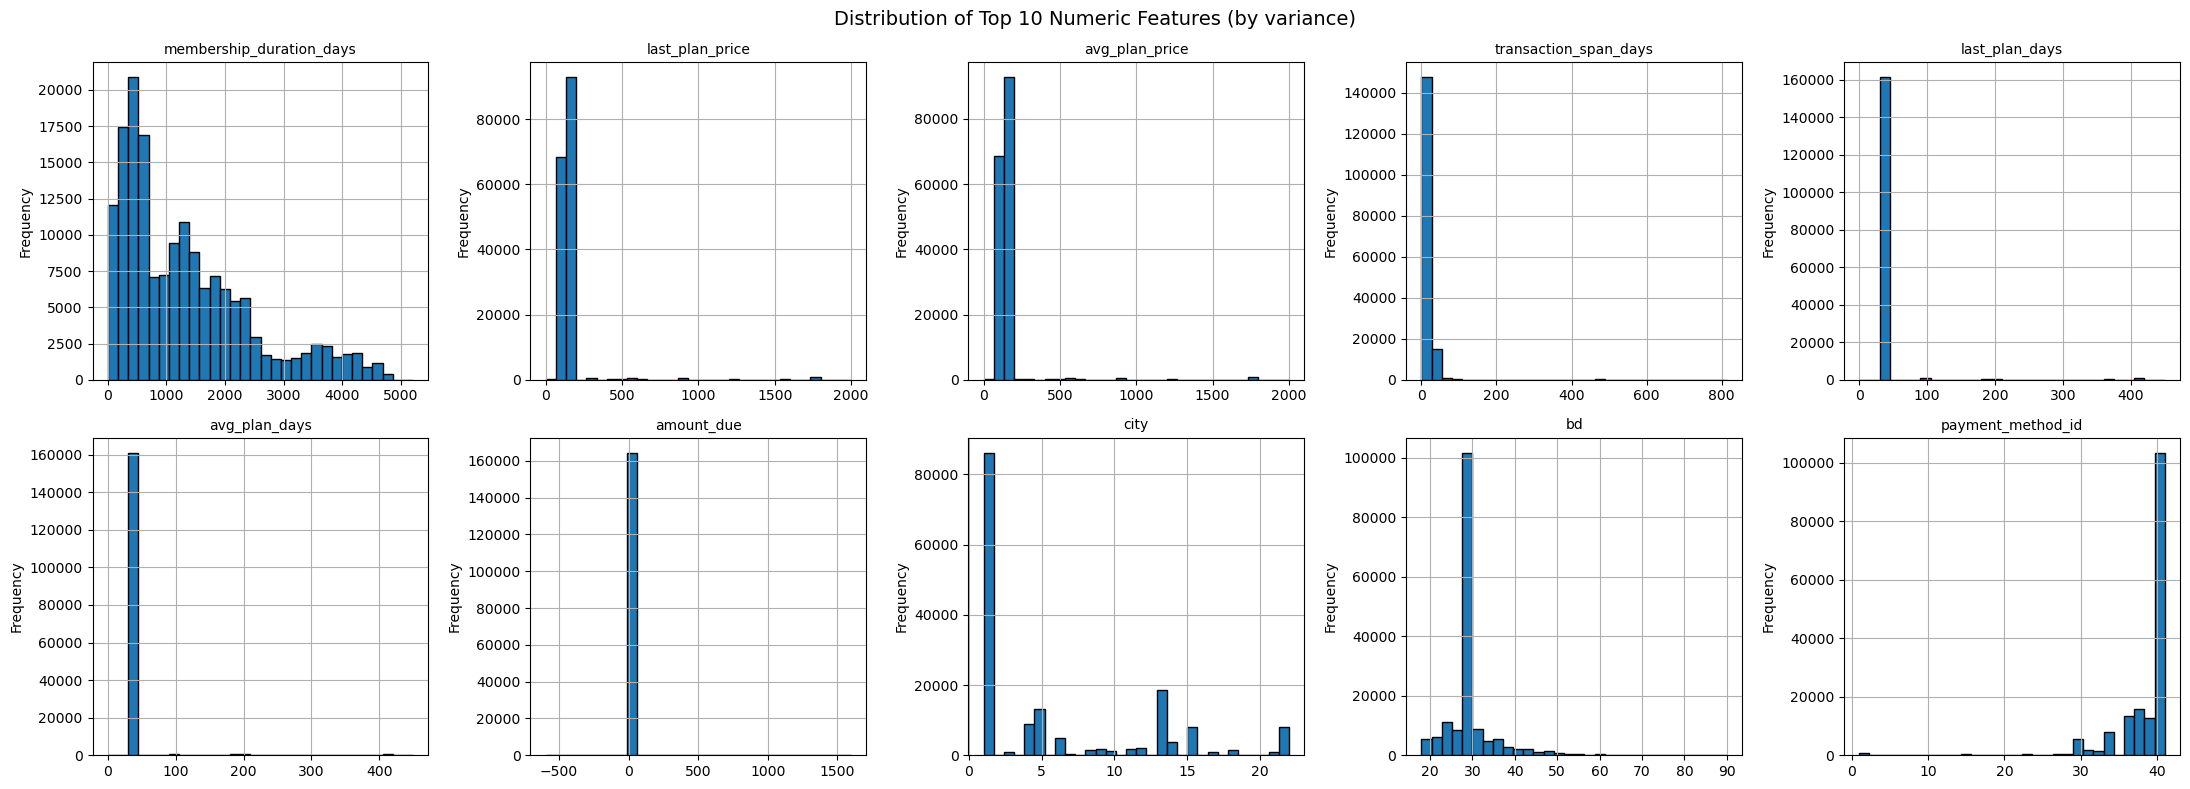

In [43]:
numeric_features = df_train_final.select_dtypes(include=['number']).drop(columns=['is_churn'])
top_10 = numeric_features.var().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, col in enumerate(top_10):
    ax = axes[i // 5, i % 5]
    df_train_final[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Frequency')
plt.suptitle('Distribution of Top 10 Numeric Features (by variance)', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Observations — Feature Distributions

- **Right-skewed distributions:** `membership_duration_days`, `transaction_span_days`, and `no_of_transactions` are heavily right-skewed — most users are relatively new with few transactions, while a long tail of power users exists. A log transform may help certain models.
- **Multi-modal clustering in price features:** `avg_plan_price` and `last_plan_price` show distinct peaks around standard plan tiers (e.g., 99, 129, 149, 180 NTD), reflecting KKBox's fixed pricing structure.
- **`amount_due` concentrated near zero:** The vast majority of users have little to no outstanding balance, with only a small number of outliers carrying larger amounts due.
- **`bd` tightly clustered around 28:** This is an artefact of median imputation — ages outside 18–90 were replaced with the median (28), so the distribution is artificially peaked rather than naturally shaped.
- **`payment_method_id` variance is misleading:** This feature is categorical (encoded as integers), so its high numeric variance does not reflect meaningful spread. It should be treated as a categorical variable in modelling, not as a continuous numeric feature.

### 2.3 Correlation Heatmap

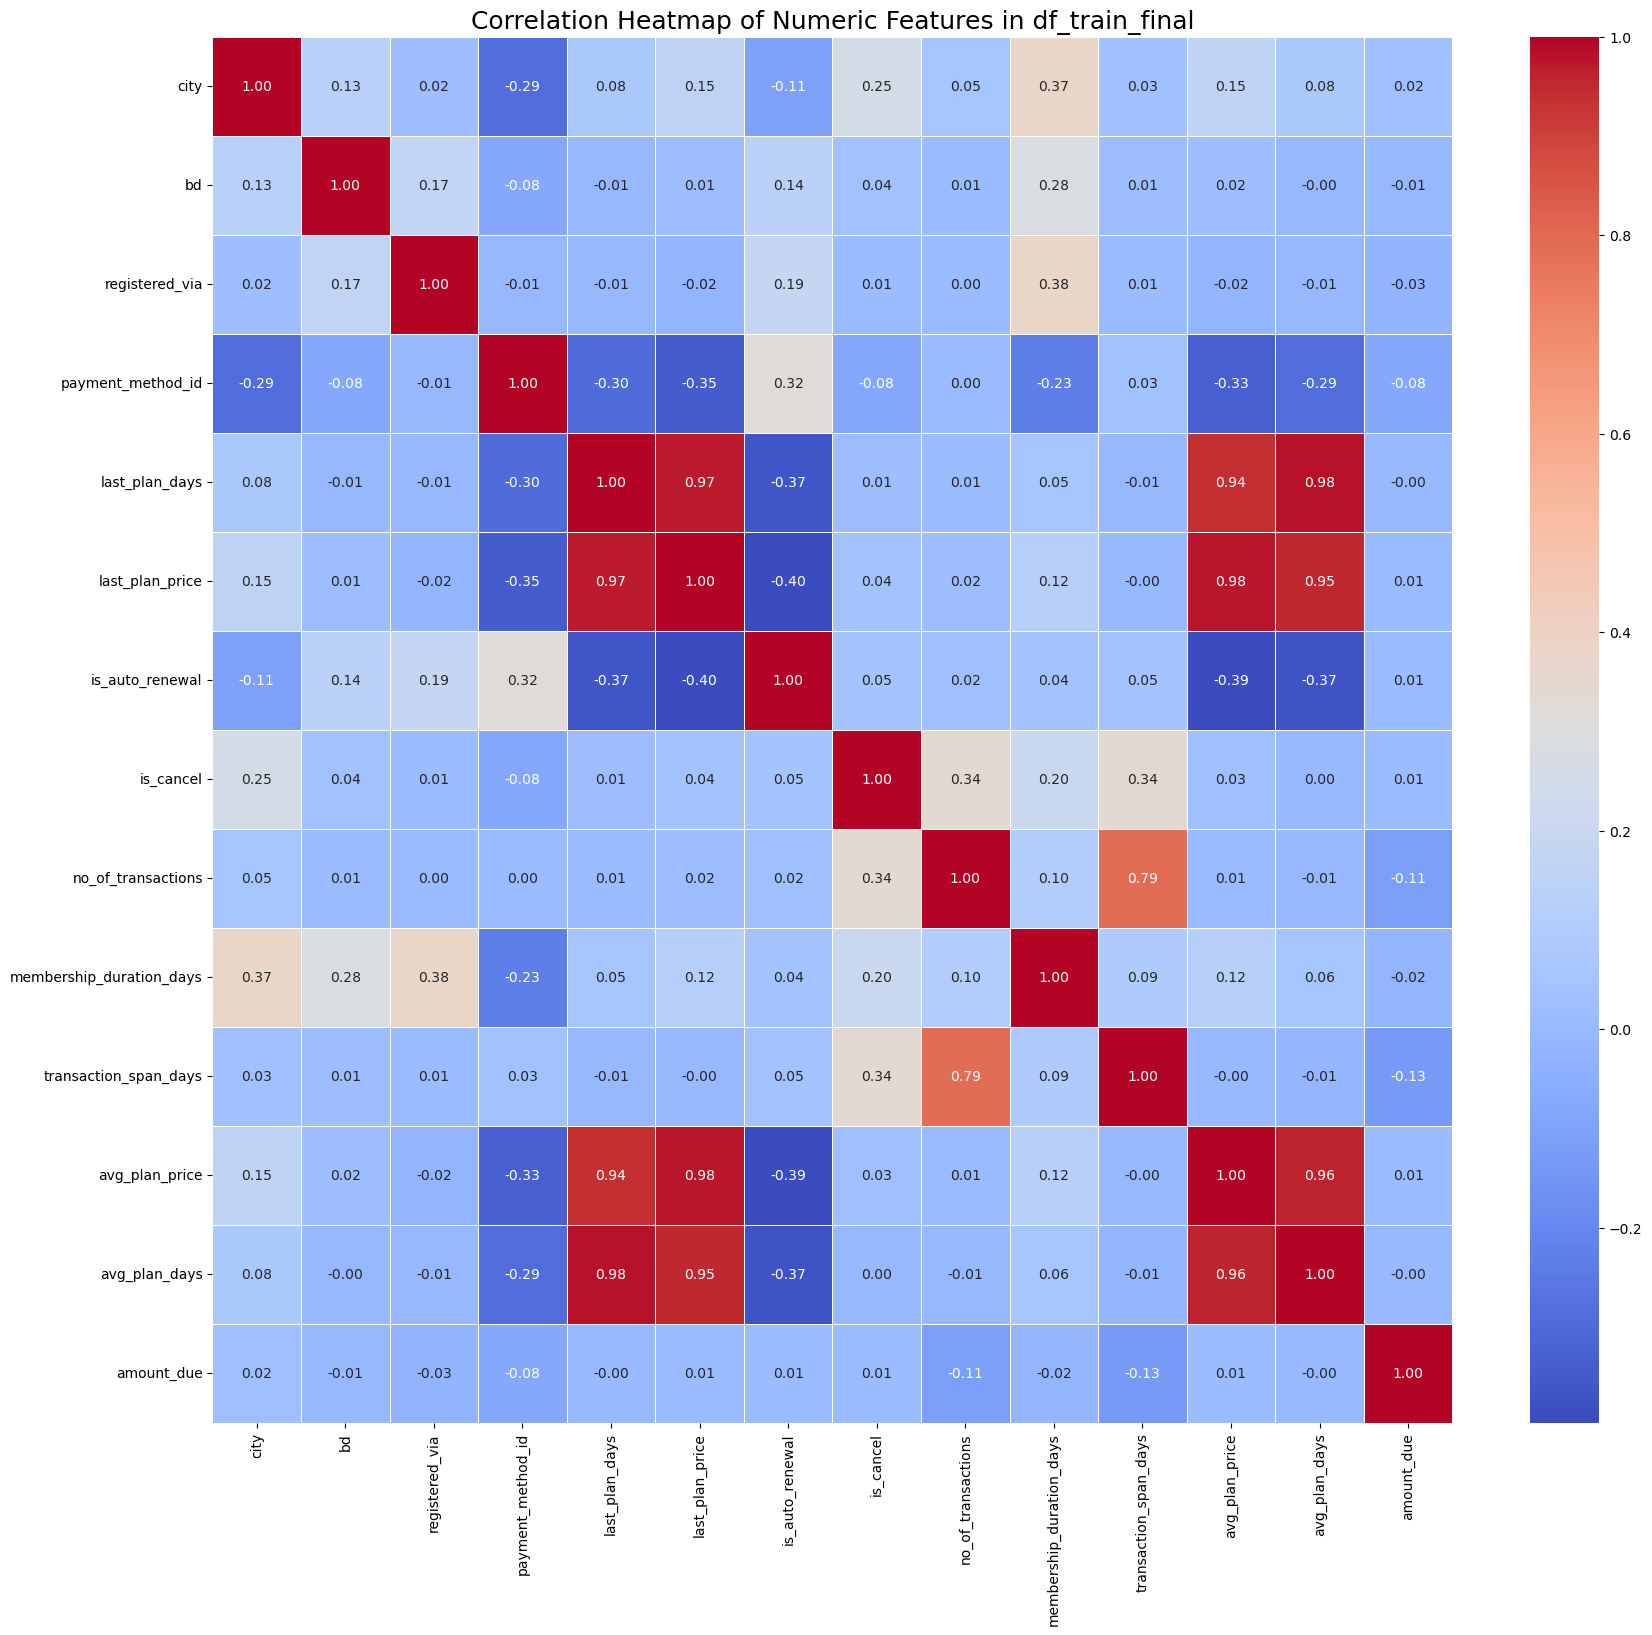

In [44]:
numeric_df = df_train_final.select_dtypes(include=['number'])
numeric_df = numeric_df.drop(columns=['is_churn'])
correlation_matrix = numeric_df.corr()


plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features in df_train_final', fontsize=18)
plt.show()

#### Key Observations — Correlation Heatmap

- **High correlation between last and average price/plan features:** `last_plan_price` and `avg_plan_price` (as well as `last_plan_days` and `avg_plan_days`) are near-identical because the majority of users have only a single transaction, making last = average. Consider dropping one from each pair or applying regularisation to mitigate multicollinearity.
- **Moderate correlation among tenure-related features:** `no_of_transactions`, `transaction_span_days`, and `membership_duration_days` are positively correlated — users who have been members longer naturally accumulate more transactions over a wider time span.
- **Low correlation for demographic features:** `bd`, `city`, and `registered_via` show weak linear relationships with other features, suggesting they capture independent information about the user.
- **Recommendation:** Before model training, consider dropping one feature from each highly correlated pair (e.g., keep `avg_plan_price`, drop `last_plan_price`) or rely on tree-based models / L2 regularisation that are more robust to collinearity.

### 2.4 Class Imbalance Analysis & Proposed Handling Strategy

In [45]:
churn_distribution = df_train_final['is_churn'].value_counts()
print("Distribution of Churn (is_churn):\n", churn_distribution)

Distribution of Churn (is_churn):
 is_churn
0    154144
1     10767
Name: count, dtype: int64


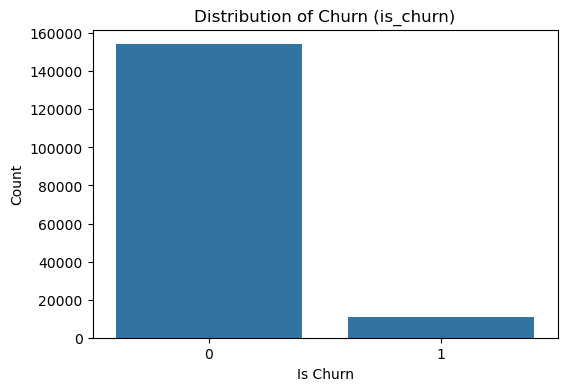

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_churn', data=df_train_final)
plt.title('Distribution of Churn (is_churn)')
plt.xlabel('Is Churn')
plt.ylabel('Count')
plt.show()

#### Recommended Strategies for This Problem


*   **Resampling Techniques:** These methods modify the training dataset to balance the class distribution.
    *   **Oversampling (e.g., SMOTE - Synthetic Minority Over-sampling Technique):** This involves increasing the number of instances in the minority class. SMOTE works by creating synthetic samples (not just duplicates) based on the feature space of existing minority class examples. It is appropriate when the amount of data in the minority class is very small, and we want to retain all available information while generating new, plausible examples.
    *   **Undersampling (e.g., RandomUnderSampler):** This involves decreasing the number of instances in the majority class. Random undersampling simply removes instances randomly from the majority class. It is appropriate when the dataset is very large, and reducing the majority class size doesn't lead to significant loss of information. However, a major drawback is the potential loss of valuable information by discarding majority class samples.

*   **Algorithm-Level Approaches:** Some machine learning algorithms are inherently better at handling imbalanced data or can be adapted to do so.
    *   **Tree-based Models (e.g., Decision Trees, Random Forests, Gradient Boosting):** These models can sometimes perform better with imbalanced data, especially when the decision boundaries are non-linear, as they split data based on features rather than linear separation. Ensemble methods like Random Forests can be particularly robust.
    *   **Cost-Sensitive Learning:** This approach assigns different misclassification costs to different classes. For instance, misclassifying a churned customer as non-churned might incur a higher cost than the reverse. This forces the model to pay more attention to the minority class during training. Many algorithms (like Support Vector Machines, Logistic Regression, and some tree-based models) can incorporate class weights.

*   **Evaluation Metrics:** When dealing with imbalanced datasets, accuracy alone is insufficient and misleading. It's crucial to use metrics that provide a more nuanced understanding of model performance:
    *   **Precision:** The proportion of correctly predicted positive observations to the total predicted positives. High precision means fewer false positives.
    *   **Recall (Sensitivity):** The proportion of correctly predicted positive observations to all observations in the actual class. High recall means fewer false negatives.
    *   **F1-Score:** The harmonic mean of precision and recall, offering a balance between the two.
    *   **AUC-ROC (Area Under the Receiver Operating Characteristic Curve):** Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model performance in separating positive and negative classes, regardless of the class distribution.

Given the observed class imbalance (154,144 non-churn vs. 10,767 churn, meaning only about 6.53% churn), the following strategies would be most suitable:

1.  **Combination of Oversampling and Undersampling:** Given the substantial number of majority class samples, a pure undersampling approach might discard too much valuable information. Conversely, pure oversampling could lead to overfitting on the synthetic minority samples. A common approach is to combine undersampling of the majority class with oversampling of the minority class (e.g., using `SMOTEENN` or `SMOTETomek`). This can help to achieve a more balanced distribution without losing too much information or introducing excessive synthetic data.
2.  **Cost-Sensitive Learning:** This is highly relevant for churn prediction. The business cost of missing a churner (false negative) is typically much higher than incorrectly identifying a non-churner as a churner (false positive). Incorporating class weights into algorithms like Logistic Regression, Support Vector Machines, or Gradient Boosting models (e.g., XGBoost, LightGBM) would allow the model to prioritize correctly identifying churners.
3.  **Ensemble Methods (e.g., Random Forest, XGBoost):** These algorithms are generally robust and perform well on imbalanced datasets. They can often capture complex patterns without explicit resampling, especially if fine-tuned correctly with class weights.
4.  **Focus on Appropriate Evaluation Metrics:** Throughout model development and evaluation, metrics like **Recall**, **F1-Score** for the minority class, and **AUC-ROC** should be prioritized over overall accuracy to ensure the model effectively identifies churners.

In [47]:
output_path = os.path.join(DATA_DIR, '..', 'processed', 'df_train_final.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_train_final.to_csv(output_path, index=False)
print(f'df_train_final.csv has been saved to {output_path}')

df_train_final.csv has been saved to ../../data/raw/../processed/df_train_final.csv
